# 2D Couette with Immersed Boundary

This notebook primarily serves as checking points along the development for 2D Couette flow with IB-LBM.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import subprocess

print(os.getcwd())
%pwd
%cd ..
print(os.getcwd())

/Users/tweng/Desktop/IB-LBM/notebook
/Users/tweng/Desktop/IB-LBM
/Users/tweng/Desktop/IB-LBM


/Users/tweng/Desktop/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Test Folder Entry
DIR = '2dcouette_test'
SUBSET = 'set2'
if not os.path.exists(os.path.join(os.getcwd(), 'temp/', SUBSET)):
    os.mkdir(os.path.join(os.getcwd(), 'temp/', SUBSET))

Re = 1/100
N = 39

# System Geometry
Nx = N * 5
Ny = N + 1

# Liquid crystal parameters
nematic_length = 0.1
alpha = 1
relaxation_time = 200
shear_rate = 0.2

# Controlled parameters
vel_top = 0
vel_bot = shear_rate * N / relaxation_time

# Simulation timescale
t_num = 100 * relaxation_time
t_disk = relaxation_time
t_lbm = 1

IBM_stencil = 2 # interpolation stencil; available values: 2, 4
wall_num_nodes = 5 * N # number of IBM nodes along each wall
wall_width = 10 # channel width
wall_stiffness = 1 # IBM spring constant

viscosity = (2 * t_lbm - 1) / 6

A = 1e-5 / N ** 2 
Gamma = 1 / (A * relaxation_time)

L = nematic_length ** 2 * A * N ** 2
U = 0
zeta = alpha * viscosity / relaxation_time
xi = 1

Parameters = str(Nx)+' '+str(Ny)+' '+str(t_num)+' '+str(t_disk)+' '+str(t_lbm)+' '+str(vel_top)+' '+str(vel_bot)+' '+str(Gamma)+' '+str(L)+' '+str(U)+' '+str(A)+' '+str(zeta)+' '+str(xi)+' '+str(IBM_stencil)+' '+str(wall_num_nodes)+' '+str(wall_width)+' '+str(wall_stiffness)

FileName = "SimulationParameters.txt"
FileID = os.path.join(os.getcwd(), 'temp/', SUBSET, FileName)
    
with open(FileID, "w") as f:
    f.write("Nx Ny TOTAL_TIME DISK_TIME LBM_TIME TOP_SPEED BOT_SPEED GAMMA FRANK_CONSTANT NEMATIC_STRENGTH NEMATIC_DENSITY ZETA FLOW_ALIGNING IBM_STENCIL WALL_NUM_NODES WALL_WIDTH WALL_STIFFNESS\n")
    f.write(Parameters)

Process = subprocess.Popen(
    [       
        'bash',
        'bash/2d_couette.sh',
        DIR,
        SUBSET,
    ],
)

Process.wait()

Starting simulation:
  Writing data at 200
  Writing data at 400
  Writing data at 600
  Writing data at 800
  Writing data at 1000
  Writing data at 1200
  Writing data at 1400
  Writing data at 1600
  Writing data at 1800
  Writing data at 2000
  Writing data at 2200
  Writing data at 2400
  Writing data at 2600
  Writing data at 2800
  Writing data at 3000
  Writing data at 3200
  Writing data at 3400
  Writing data at 3600
  Writing data at 3800
  Writing data at 4000
  Writing data at 4200
  Writing data at 4400
  Writing data at 4600
  Writing data at 4800
  Writing data at 5000
  Writing data at 5200
  Writing data at 5400
  Writing data at 5600
  Writing data at 5800
  Writing data at 6000
  Writing data at 6200
  Writing data at 6400
  Writing data at 6600
  Writing data at 6800
  Writing data at 7000
  Writing data at 7200
  Writing data at 7400
  Writing data at 7600
  Writing data at 7800
  Writing data at 8000
  Writing data at 8200
  Writing data at 8400
  Writing data at

0

In [3]:
# %cd ../../../IB-LBM
%cd ../Data/2dcouette_test/set2/
%pwd

/Users/tweng/Desktop/Data/2dcouette_test/set2


/Users/tweng/Desktop/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'/Users/tweng/Desktop/Data/2dcouette_test/set2'

In [4]:
import pandas as pd
import numpy as np
from glob import glob
import os

Parameters = './SimulationParameters.txt'
pf = pd.read_csv(Parameters, delimiter='\s', header=0, engine='python')
Nx = int(pf['Nx'].to_numpy()[0])
Ny = int(pf['Ny'].to_numpy()[0])
LID_SPEED = pf['BOT_SPEED'].to_numpy()[0]

t_lbm = pf['LBM_TIME'].to_numpy()[0]
VISCOSITY = (t_lbm - 0.5) / 3

GAMMA = pf['GAMMA'].to_numpy()[0]
ZETA = pf['ZETA'].to_numpy()[0]
NEMATIC_DENSITY = pf['NEMATIC_DENSITY'].to_numpy()[0]
NEMATIC_STRENGTH = pf['NEMATIC_STRENGTH'].to_numpy()[0]
FRANK_CONSTANT = pf['FRANK_CONSTANT'].to_numpy()[0]

TOTAL_TIME = pf['TOTAL_TIME'].to_numpy()[0]
DISK_TIME = pf['DISK_TIME'].to_numpy()[0]

TOTAL_TIME = DISK_TIME * len(glob(os.getcwd()+'/data/*.dat'))
time_steps = int(TOTAL_TIME / DISK_TIME)

shape = (Nx, Ny)
temporal_shape = (time_steps, Nx, Ny)

density = np.zeros(temporal_shape)
vel_x = np.zeros(temporal_shape)
vel_y = np.zeros(temporal_shape)

density_Temp = np.zeros(shape)
vel_x_Temp = np.zeros(shape)
vel_y_Temp = np.zeros(shape)

for t in range(time_steps):
    data_file = 'data/fluid_t%d.dat' %((t+1) * DISK_TIME)
    df = pd.read_csv(data_file, delimiter='\s', header=0, engine='python') 

    # read in with delimiter of one-space separation
    # convert input into numpy array
    density_Temp = np.reshape(df['density'].to_numpy(), shape)
    vel_x_Temp = np.reshape(df['vel_x'].to_numpy(), shape)
    vel_y_Temp = np.reshape(df['vel_y'].to_numpy(), shape)

    density[t] = density_Temp
    vel_x[t] = vel_x_Temp
    vel_y[t] = vel_y_Temp


np.savez_compressed('Data.npz', 
                    Nx=Nx, Ny=Ny,
                    VISCOSITY=VISCOSITY, GAMMA=GAMMA, 
                    LID_SPEED=LID_SPEED, ZETA=ZETA,
                    FRANK_CONSTANT=FRANK_CONSTANT, 
                    NEMATIC_DENSITY=NEMATIC_DENSITY,
                    
                    density=density,
                    vel_x=vel_x, vel_y=vel_y, 
                    )

/var/folders/01/wf5bk3m54yg_2783pvgmjnn40000gn/T/ipykernel_10823/2400117558.py:28: RuntimeWarning: invalid value encountered in sqrt
  active_correlation_length = np.sqrt(FRANK_CONSTANT / -ZETA)
/var/folders/01/wf5bk3m54yg_2783pvgmjnn40000gn/T/ipykernel_10823/2400117558.py:30: RuntimeWarning: invalid value encountered in sqrt
  saloni_Activity = (Nx - 1) * np.sqrt(-ZETA / FRANK_CONSTANT)


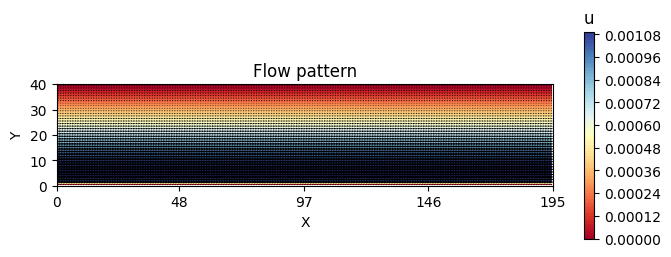

In [5]:
import matplotlib.pyplot as plt

# PARAMETERS #

# READ-IN PARAMETER FILE
dataFile = np.load('Data.npz')

Nx = dataFile['Nx']
Ny = dataFile['Ny']

LID_SPEED = dataFile['LID_SPEED']
VISCOSITY = dataFile['VISCOSITY']
FRANK_CONSTANT = dataFile['FRANK_CONSTANT']
GAMMA = dataFile['GAMMA']
NEMATIC_DENSITY = dataFile['NEMATIC_DENSITY']
ZETA = dataFile['ZETA']

density = dataFile['density']
vel_x = dataFile['vel_x']
vel_y = dataFile['vel_y']


# OUTPUT A NOTE WITH DIMENSIONLESS NUMBERS
Re = (Nx - 1) * LID_SPEED / VISCOSITY
Er = (Nx - 1) * LID_SPEED / (FRANK_CONSTANT * GAMMA)
Ac = -ZETA * (Nx - 1) / (VISCOSITY * LID_SPEED)
nematic_correlation_length = np.sqrt(FRANK_CONSTANT / NEMATIC_DENSITY)
active_correlation_length = np.sqrt(FRANK_CONSTANT / -ZETA)
nematic_correlation_time = 1 / (NEMATIC_DENSITY * GAMMA)
saloni_Activity = (Nx - 1) * np.sqrt(-ZETA / FRANK_CONSTANT)


# MAKE ANALYSIS DIRECTORY #
if not os.path.exists('frames'):
       os.mkdir('frames')
if not os.path.exists('slices'):
       os.mkdir('slices')
if not os.path.exists('Analysis'):
       os.mkdir('Analysis')


# Projecting velocities, not averaging
# due to matplotlib array indexing, np.swapaxes method is used

speed = np.sqrt(np.square(vel_x) + np.square(vel_y))

x_ticks = np.linspace(0,Nx,5,endpoint=True,dtype=int)
y_ticks = np.linspace(0,Ny,5,endpoint=True,dtype=int)


for t in range(time_steps):

       v_x = np.swapaxes(vel_x[t,:,:],0,1)
       v_y = np.swapaxes(vel_y[t,:,:],0,1)
       v = np.swapaxes(speed[t,:,:],0,1)

       fig, ax = plt.subplots(figsize=(8, 3))
       # fig.suptitle(SUPTITLE)
       plt.subplots_adjust(top=0.8)
       x, y = np.meshgrid((np.arange(Nx) + 0.5), (np.arange(Ny) + 0.5))
       im = ax.contourf(x, y, v, 80, cmap='RdYlBu')
       clb = plt.colorbar(im,ax=ax)
       clb.ax.set_title('u')
       ax.streamplot(x, y, v_x, v_y, density=1.5, color='black')
       ax.set(xlim=(0, Nx), ylim=(0, Ny),
              aspect='equal',
              xticks=x_ticks, yticks=y_ticks,
              xlabel='X', ylabel='Y',
              title='Flow pattern')

       # plt.show()
       plt.savefig('frames/flow_t%03d.png'%(t+1))
       plt.close()

       fig, ax = plt.subplots(figsize=(8, 3))
       # fig.suptitle(SUPTITLE)
       plt.subplots_adjust(top=0.8)
       x, y = np.meshgrid((np.arange(Nx) + 0.5), (np.arange(Ny) + 0.5))
       im = ax.contourf(x, y, v, 80, cmap='RdYlBu')
       clb = plt.colorbar(im,ax=ax)
       clb.ax.set_title('u')
       ax.quiver(x, y, v_x, v_y,
                     pivot='mid', units='inches')

       ax.set(xlim=(0, Nx), ylim=(0, Ny),
              aspect='equal',
              xticks=x_ticks, yticks=y_ticks,
              xlabel='X', ylabel='Y',
              title='Flow pattern')
       if t == (time_steps - 1):
              plt.show()
       plt.savefig('frames/flowfield_t%03d.png'%(t+1))
       plt.close()



